<a href="https://colab.research.google.com/github/qqqyc1017/COMP9444_Project/blob/main/COMP9444.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SVM + KNN — Environment Setup

Run all cells in this section whenever a new Colab runtime is started.:


所有训练参数
import
pip
结果pre recall f1 gm mauc acc

In [14]:
!pip install ultralytics albumentations opencv-python scikit-learn
!pip install -q scikit-image joblib seaborn

In [15]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torchvision

from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cpu
Device: cpu


In [16]:
# Connect Google Colab to the shared Google Drive dataset

from google.colab import drive
from pathlib import Path

# Mount Google Drive
drive.mount("/content/drive")

# Shared project paths
PROJECT_DIR = Path(
    "/content/drive/MyDrive/COMP9444_Project"
)

DATASET_DIR = PROJECT_DIR / "Dataset"
IMAGE_DIR = DATASET_DIR / "images"

TRAIN_FILE = DATASET_DIR / "train.txt"
VAL_FILE = DATASET_DIR / "val.txt"
TEST_FILE = DATASET_DIR / "test.txt"
CLASSES_FILE = DATASET_DIR / "classes.txt"

# Check that all required files exist
required_paths = {
    "Project folder": PROJECT_DIR,
    "Dataset folder": DATASET_DIR,
    "Image folder": IMAGE_DIR,
    "Training split": TRAIN_FILE,
    "Validation split": VAL_FILE,
    "Test split": TEST_FILE,
    "Class names": CLASSES_FILE,
}

all_files_found = True

for name, path in required_paths.items():
    exists = path.exists()

    print(
        f"{name:20}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )

    print(f"  {path}")

    all_files_found = (
        all_files_found and exists
    )

if not all_files_found:
    raise FileNotFoundError(
        "Some IP102 files are missing. "
        "Check the Google Drive path."
    )

print("\nIP102 dataset connected successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder      : FOUND
  /content/drive/MyDrive/COMP9444_Project
Dataset folder      : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset
Image folder        : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/images
Training split      : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/train.txt
Validation split    : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/val.txt
Test split          : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/test.txt
Class names         : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/classes.txt

IP102 dataset connected successfully.


In [17]:
from google.colab import drive

try:
    drive.flush_and_unmount()
except Exception:
    pass

drive.mount(
    "/content/drive",
    force_remount=True,
)

print("Google Drive remounted.")

Mounted at /content/drive
Google Drive remounted.


In [18]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/COMP9444_Project"
)

DATASET_DIR = PROJECT_DIR / "Dataset"
IMAGE_DIR = DATASET_DIR / "images"

TRAIN_FILE = DATASET_DIR / "train.txt"
VAL_FILE = DATASET_DIR / "val.txt"
TEST_FILE = DATASET_DIR / "test.txt"
CLASSES_FILE = DATASET_DIR / "classes.txt"

In [19]:
from PIL import Image

test_image_path = (
    IMAGE_DIR / "00002.jpg"
)

print("Testing:", test_image_path)

try:
    print("Exists:", test_image_path.exists())
    print("Size:", test_image_path.stat().st_size)

    with Image.open(test_image_path) as image:
        image.verify()

    print("Image is readable.")

except Exception as error:
    print(
        "Image read failed:",
        type(error).__name__,
        error,
    )

Testing: /content/drive/MyDrive/COMP9444_Project/Dataset/images/00002.jpg
Exists: True
Size: 17985
Image is readable.


**final version**

In [20]:
from google.colab import drive
from pathlib import Path
import random

import numpy as np
import pandas as pd

# Mount Google Drive only once
drive.mount("/content/drive")

SEED = 9444
random.seed(SEED)
np.random.seed(SEED)

# Project and dataset paths
PROJECT_DIR = Path(
    "/content/drive/MyDrive/COMP9444_Project"
)

DATASET_DIR = PROJECT_DIR / "Dataset"
IMAGE_DIR = DATASET_DIR / "images"

TRAIN_FILE = DATASET_DIR / "train.txt"
VAL_FILE = DATASET_DIR / "val.txt"
TEST_FILE = DATASET_DIR / "test.txt"
CLASSES_FILE = DATASET_DIR / "classes.txt"

# Output paths
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"
CACHE_DIR = PROJECT_DIR / "cache"

# Check dataset files
required_paths = {
    "Project folder": PROJECT_DIR,
    "Dataset folder": DATASET_DIR,
    "Image folder": IMAGE_DIR,
    "Training split": TRAIN_FILE,
    "Validation split": VAL_FILE,
    "Test split": TEST_FILE,
    "Class names": CLASSES_FILE,
}

missing_paths = []

for name, path in required_paths.items():
    exists = path.exists()
    print(f"{name:20}: {'FOUND' if exists else 'MISSING'}")
    print(f"  {path}")

    if not exists:
        missing_paths.append(path)

if missing_paths:
    raise FileNotFoundError(
        f"Missing IP102 paths: {missing_paths}"
    )

# Create output directories
for directory in [
    MODEL_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    CACHE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("\nIP102 dataset connected successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder      : FOUND
  /content/drive/MyDrive/COMP9444_Project
Dataset folder      : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset
Image folder        : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/images
Training split      : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/train.txt
Validation split    : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/val.txt
Test split          : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/test.txt
Class names         : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/classes.txt

IP102 dataset connected successfully.


In [21]:
def load_ip102_split(split_file):
    dataframe = pd.read_csv(
        split_file,
        sep=r"\s+",
        header=None,
        names=["file", "class"],
    )

    # Remove possible folder prefixes
    dataframe["file"] = dataframe["file"].apply(
        lambda value: Path(str(value)).name
    )

    dataframe["class"] = dataframe["class"].astype(
        np.int64
    )

    return dataframe


train = load_ip102_split(TRAIN_FILE)
val = load_ip102_split(VAL_FILE)
test = load_ip102_split(TEST_FILE)

print("Training images:", len(train))
print("Validation images:", len(val))
print("Test images:", len(test))

print("Training classes:", train["class"].nunique())
print("Validation classes:", val["class"].nunique())
print("Test classes:", test["class"].nunique())

display(train.head())

# Test one image path
sample_image = IMAGE_DIR / train.iloc[0]["file"]

if not sample_image.exists():
    raise FileNotFoundError(
        f"Example image is missing: {sample_image}"
    )

print("\nDataset splits loaded successfully.")
print("Example image:", sample_image)

Training images: 45095
Validation images: 7508
Test images: 22619
Training classes: 102
Validation classes: 102
Test classes: 102


,file,class
0,00002.jpg,0
1,00003.jpg,0
2,00005.jpg,0
3,00006.jpg,0
4,00008.jpg,0



Dataset splits loaded successfully.
Example image: /content/drive/MyDrive/COMP9444_Project/Dataset/images/00002.jpg


In [22]:
FEATURE_SIZE = 64
PCA_COMPONENTS = 64
SVM_C = 1.0
KNN_K = 5
FEATURE_WORKERS = 4

# 100 for faster experiments; 0 for the complete training set
MAX_TRAIN_PER_CLASS = 100

# Check variables without directly referencing undefined names
required_variable_names = [
    "train",
    "val",
    "test",
    "IMAGE_DIR",
    "CLASSES_FILE",
    "MODEL_DIR",
    "OUTPUT_DIR",
    "FIGURE_DIR",
    "CACHE_DIR",
]

missing_variables = [
    name
    for name in required_variable_names
    if name not in globals()
]

if missing_variables:
    raise NameError(
        "Run the Drive configuration and data-loading "
        f"cells first. Missing variables: {missing_variables}"
    )

# SVM + KNN Drive directories
SVM_KNN_OUTPUT_DIR = OUTPUT_DIR / "svm_knn"
SVM_KNN_FIGURE_DIR = FIGURE_DIR / "svm_knn"
SVM_KNN_CACHE_DIR = CACHE_DIR / "svm_knn"
SVM_KNN_MODEL_DIR = MODEL_DIR / "svm_knn"

for directory in [
    SVM_KNN_OUTPUT_DIR,
    SVM_KNN_FIGURE_DIR,
    SVM_KNN_CACHE_DIR,
    SVM_KNN_MODEL_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

configuration = pd.DataFrame({
    "Parameter": [
        "feature_size",
        "pca_components",
        "svm_c",
        "knn_k",
        "feature_workers",
        "max_train_per_class",
        "seed",
    ],
    "Value": [
        FEATURE_SIZE,
        PCA_COMPONENTS,
        SVM_C,
        KNN_K,
        FEATURE_WORKERS,
        MAX_TRAIN_PER_CLASS,
        SEED,
    ],
})

display(configuration)

print("Project directory:", PROJECT_DIR)
print("Image directory:", IMAGE_DIR)
print("Output directory:", SVM_KNN_OUTPUT_DIR)
print("Figure directory:", SVM_KNN_FIGURE_DIR)
print("Cache directory:", SVM_KNN_CACHE_DIR)
print("Model directory:", SVM_KNN_MODEL_DIR)

,Parameter,Value
0,feature_size,64.0
1,pca_components,64.0
2,svm_c,1.0
3,knn_k,5.0
4,feature_workers,4.0
5,max_train_per_class,100.0
6,seed,9444.0


Project directory: /content/drive/MyDrive/COMP9444_Project
Image directory: /content/drive/MyDrive/COMP9444_Project/Dataset/images
Output directory: /content/drive/MyDrive/COMP9444_Project/outputs/svm_knn
Figure directory: /content/drive/MyDrive/COMP9444_Project/figures/svm_knn
Cache directory: /content/drive/MyDrive/COMP9444_Project/cache/svm_knn
Model directory: /content/drive/MyDrive/COMP9444_Project/models/svm_knn


In [24]:
FEATURE_SIZE = 64
PCA_COMPONENTS = 64
SVM_C = 1.0
KNN_K = 5
FEATURE_WORKERS = 4

MAX_TRAIN_PER_CLASS = 0 #use 100 or 200 to make a faster training process, use 0 in the final training

# Confirm that the group preprocessing has been executed
required_variables = {
    "train": train,
    "val": val,
    "test": test,
    "IMAGE_DIR": IMAGE_DIR,
    "CLASSES_FILE": CLASSES_FILE,
}
for variable_name, variable_value in (required_variables.items()):
    if variable_value is None:
        raise ValueError(f"{variable_name} has not been created.")
# Drive output directories (created in the setup cell)
SVM_KNN_OUTPUT_DIR = OUTPUT_DIR / "svm_knn"
SVM_KNN_FIGURE_DIR = FIGURE_DIR / "svm_knn"
SVM_KNN_CACHE_DIR = CACHE_DIR / "svm_knn"
SVM_KNN_MODEL_DIR = MODEL_DIR / "svm_knn"

for directory in [
    SVM_KNN_OUTPUT_DIR,
    SVM_KNN_FIGURE_DIR,
    SVM_KNN_CACHE_DIR,
    SVM_KNN_MODEL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True,)
configuration = pd.DataFrame({
    "Parameter": [
        "feature_size",
        "pca_components",
        "svm_c",
        "knn_k",
        "feature_workers",
        "max_train_per_class",
        "seed",
    ],
    "Value": [
        FEATURE_SIZE,
        PCA_COMPONENTS,
        SVM_C,
        KNN_K,
        FEATURE_WORKERS,
        MAX_TRAIN_PER_CLASS,
        SEED,
    ],
})
display(configuration)

print("Project directory:", PROJECT_DIR)
print("Image directory:", IMAGE_DIR)
print("Output directory:", SVM_KNN_OUTPUT_DIR)


,Parameter,Value
0,feature_size,64.0
1,pca_components,64.0
2,svm_c,1.0
3,knn_k,5.0
4,feature_workers,4.0
5,max_train_per_class,0.0
6,seed,9444.0


Project directory: /content/drive/MyDrive/COMP9444_Project
Image directory: /content/drive/MyDrive/COMP9444_Project/Dataset/images
Output directory: /content/drive/MyDrive/COMP9444_Project/outputs/svm_knn


In [25]:
# Create a continuous label mapping
raw_train_labels = sorted(train["class"].unique().tolist())

label_map = {raw_label: new_label
    for new_label, raw_label in enumerate(raw_train_labels)}
NUM_CLASSES = len(raw_train_labels)
assert NUM_CLASSES == 102, (f"Expected 102 classes, found {NUM_CLASSES}.")

def dataframe_to_records(dataframe):
    """
    Convert the group DataFrame into:
        [(image_path, continuous_label), ...]
    """
    output_records = []
    for filename, raw_label in zip(dataframe["file"], dataframe["class"],):
        if raw_label not in label_map:
            raise ValueError(f"Unknown class label: {raw_label}")
        output_records.append(
            (
                IMAGE_DIR / Path(filename).name,
                label_map[int(raw_label)],
            )
        )
    return output_records
records = {
    "train": dataframe_to_records(train),
    "val": dataframe_to_records(val),
    "test": dataframe_to_records(test),}

print("Training records:", len(records["train"]),)
print("Validation records:", len(records["val"]),)
print("Test records:", len(records["test"]),)
print("Number of classes:", NUM_CLASSES,)
assert len(records["train"]) == len(train)
assert len(records["val"]) == len(val)
assert len(records["test"]) == len(test)
# Load IP102 class names
class_lines = [line.strip()
    for line in CLASSES_FILE.read_text(
        encoding="utf-8").splitlines()
    if line.strip()
]
class_names = []
for line in class_lines:
    parts = line.split(maxsplit=1)
    if (len(parts) == 2 and parts[0].isdigit()):
        class_names.append(parts[1])
    else:
        class_names.append(line)

if len(class_names) != NUM_CLASSES:
    print("Warning: classes.txt does not match " "the number of dataset classes.")
    class_names = [str(raw_label)
        for raw_label in raw_train_labels]
print("Number of class names:", len(class_names),)
print("First five classes:", class_names[:5],)

Training records: 45095
Validation records: 7508
Test records: 22619
Number of classes: 102
Number of class names: 102
First five classes: ['rice leaf roller', 'rice leaf caterpillar', 'paddy stem maggot', 'asiatic rice borer', 'yellow rice borer']


In [26]:
def limit_samples_per_class(samples, maximum_per_class,):
    if maximum_per_class <= 0:
        return list(samples)
    rng = np.random.default_rng(SEED)
    grouped_samples = {}
    for sample in samples:
        label = sample[1]
        grouped_samples.setdefault(label, [],).append(sample)
    selected_samples = []
    for label in sorted(grouped_samples):
        class_samples = grouped_samples[label]
        number_to_select = min(
            maximum_per_class,
            len(class_samples),)
        selected_indices = rng.choice(
            len(class_samples),
            size=number_to_select,
            replace=False,)
        selected_samples.extend([class_samples[index]
            for index in selected_indices])

    rng.shuffle(selected_samples)
    return selected_samples

selected_train_records = (
    limit_samples_per_class(
        records["train"],
        MAX_TRAIN_PER_CLASS,))
selected_labels = np.asarray(
    [
        label
        for _, label
        in selected_train_records
    ], dtype=np.int64, )
selected_counts = np.bincount(selected_labels, minlength=NUM_CLASSES,)
assert (np.count_nonzero(selected_counts) == NUM_CLASSES), "Some classes are missing."

if MAX_TRAIN_PER_CLASS > 0:
    assert (selected_counts.max() <= MAX_TRAIN_PER_CLASS)
print("Original training images:", len(records["train"]),)
print("Selected training images:", len(selected_train_records),)
print("Selected classes:", np.count_nonzero(selected_counts),)
print("Smallest selected class:", selected_counts.min(),)
print("Largest selected class:", selected_counts.max(),)

Original training images: 45095
Selected training images: 45095
Selected classes: 102
Smallest selected class: 42
Largest selected class: 3444


In [27]:
def load_image_with_retry(
    image_path,
    maximum_attempts=3,
    wait_seconds=1,
):
    last_error = None
    for attempt in range(1, maximum_attempts + 1,):
        try:
            with Image.open(image_path) as image:
                return (image.convert("RGB").copy())
        except OSError as error:
            last_error = error
            print(
                f"Image read error "
                f"({attempt}/{maximum_attempts}): "
                f"{image_path.name}"
            )

            time.sleep(wait_seconds)

    raise OSError(f"Failed to read {image_path}") from last_error

def extract_image_feature(image_path):
    image = load_image_with_retry(image_path)
    image = image.resize((FEATURE_SIZE, FEATURE_SIZE,))
    rgb = np.asarray(image, dtype=np.float32,) / 255.0
    # HOG shape features
    hog_feature = hog(
        rgb2gray(rgb),
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    )
    # HSV colour histograms
    hsv = rgb2hsv(rgb)
    colour_feature = np.concatenate([
        np.histogram(
            hsv[..., channel],
            bins=16,
            range=(0, 1),
            density=True,
        )[0]
        for channel in range(3)
    ])

    combined_feature = np.concatenate([hog_feature, colour_feature,])
    return combined_feature.astype(np.float32)
def extract_split_features(samples, description,):
    image_paths = [image_path for image_path, _ in samples]
    labels = np.asarray([label for _, label in samples], dtype=np.int64,)
    with ThreadPoolExecutor(
        max_workers=FEATURE_WORKERS
    ) as executor:
        feature_list = list(
            tqdm(executor.map(extract_image_feature, image_paths,),
                total=len(image_paths), desc=description,))
    features = np.stack(feature_list)
    return features, labels
print("Feature extraction functions created.")

Feature extraction functions created.


In [28]:
# Dependencies for SVM + KNN feature extraction

import time
from concurrent.futures import ThreadPoolExecutor

import numpy as np

from PIL import Image, ImageFile
from tqdm.auto import tqdm

from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import hog

ImageFile.LOAD_TRUNCATED_IMAGES = True

print("Feature extraction dependencies imported.")

Feature extraction dependencies imported.


In [29]:
cache_file = SVM_KNN_CACHE_DIR / (
    f"svm_knn_features_"
    f"size{FEATURE_SIZE}_"
    f"hog9_hsv16_"
    f"cap{MAX_TRAIN_PER_CLASS}_"
    f"seed{SEED}.npz"
)

if cache_file.exists():
    print("Loading cached features:")
    print(cache_file)
    with np.load(cache_file) as cache:
        x_train = cache["x_train"]
        y_train = cache["y_train"]
        x_val = cache["x_val"]
        y_val = cache["y_val"]
        x_test = cache["x_test"]
        y_test = cache["y_test"]
else:
    x_train, y_train = (extract_split_features(selected_train_records, "Extracting training features",))
    x_val, y_val = (extract_split_features(records["val"], "Extracting validation features",))
    x_test, y_test = (extract_split_features(records["test"], "Extracting test features",))
    np.savez_compressed(
        cache_file,
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        x_test=x_test,
        y_test=y_test,
    )
    print("Feature cache saved:")
    print(cache_file)
print("Training features:", x_train.shape)
print("Validation features:", x_val.shape)
print("Test features:", x_test.shape)

Extracting training features:   0%|          | 0/45095 [00:00<?, ?it/s]

Extracting validation features:   0%|          | 0/7508 [00:00<?, ?it/s]

Extracting test features:   0%|          | 0/22619 [00:00<?, ?it/s]

Feature cache saved:
/content/drive/MyDrive/COMP9444_Project/cache/svm_knn/svm_knn_features_size64_hog9_hsv16_cap0_seed9444.npz
Training features: (45095, 1812)
Validation features: (7508, 1812)
Test features: (22619, 1812)


In [32]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Fit preprocessing only on training data
feature_scaler = StandardScaler()
x_train_scaled = feature_scaler.fit_transform(x_train)
x_val_scaled = feature_scaler.transform(x_val)
x_test_scaled = feature_scaler.transform(x_test)
number_of_components = min(PCA_COMPONENTS, x_train_scaled.shape[0] - 1, x_train_scaled.shape[1],)

pca = PCA(
    n_components=number_of_components,
    whiten=True,
    svd_solver="randomized",
    random_state=SEED,
)
x_train_final = pca.fit_transform(x_train_scaled)
x_val_final = pca.transform(x_val_scaled)
x_test_final = pca.transform(x_test_scaled)
print("Original feature dimension:", x_train.shape[1],)
print("PCA feature dimension:", x_train_final.shape[1],)
print("Explained variance ratio:", round(float(pca.explained_variance_ratio_.sum()), 4, ),)
print("Training PCA features:", x_train_final.shape,)
print("Validation PCA features:", x_val_final.shape,)
print("Test PCA features:", x_test_final.shape,)

Original feature dimension: 1812
PCA feature dimension: 64
Explained variance ratio: 0.4834
Training PCA features: (45095, 64)
Validation PCA features: (7508, 64)
Test PCA features: (22619, 64)


In [34]:
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import time
svm_model = LinearSVC(
    C=SVM_C,
    class_weight="balanced",
    dual="auto",
    max_iter=5000,
    random_state=SEED,)
knn_model = KNeighborsClassifier(
    n_neighbors=KNN_K,
    weights="distance",
    n_jobs=-1,)

print("Start training SVM...")
svm_start_time = time.perf_counter()
svm_model.fit(x_train_final, y_train,)
svm_training_time = (time.perf_counter() - svm_start_time)

print("Start training KNN...")
knn_start_time = time.perf_counter()
knn_model.fit(x_train_final, y_train,)
knn_training_time = (time.perf_counter() - knn_start_time)

assert np.array_equal(svm_model.classes_, knn_model.classes_, ), "SVM and KNN class orders do not match."
print(
    f"SVM training time: "
    f"{svm_training_time:.2f} seconds")
print(f"KNN fitting time: " f"{knn_training_time:.2f} seconds")

Start training SVM...
Start training KNN...
SVM training time: 29.88 seconds
KNN fitting time: 0.01 seconds


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

from imblearn.metrics import geometric_mean_score
def stable_softmax(values):
    values = (values - values.max(axis=1, keepdims=True,))
    exponential = np.exp(values)
    return (exponential / exponential.sum(axis=1, keepdims=True, ))

class_order = svm_model.classes_
svm_val_scores = stable_softmax(svm_model.decision_function(x_val_final))
knn_val_scores = knn_model.predict_proba(x_val_final)
svm_val_predictions = class_order[svm_val_scores.argmax(axis=1)]
knn_val_predictions = class_order[knn_val_scores.argmax(axis=1)]
svm_val_accuracy = accuracy_score(y_val, svm_val_predictions,)
knn_val_accuracy = accuracy_score(y_val, knn_val_predictions,)
svm_weight = (svm_val_accuracy / max(svm_val_accuracy + knn_val_accuracy, 1e-12,))
knn_weight = 1.0 - svm_weight
print(f"SVM validation accuracy: " f"{svm_val_accuracy:.4f}")
print(f"KNN validation accuracy: " f"{knn_val_accuracy:.4f}")
print(f"SVM ensemble weight: " f"{svm_weight:.4f}")
print(f"KNN ensemble weight: " f"{knn_weight:.4f}")
# Evaluation function
def evaluate_classification_scores(y_true, scores, score_class_order,):
    predictions = score_class_order[scores.argmax(axis=1)]
    precision = precision_score( y_true, predictions, average="macro", zero_division=0,)
    recall = recall_score( y_true, predictions, average="macro", zero_division=0,)
    f1 = f1_score(y_true, predictions, average="macro", zero_division=0,)
    gm = geometric_mean_score(
        y_true,
        predictions,
        average="macro",)

    mauc = roc_auc_score(y_true, scores, multi_class="ovr", average="macro", labels=score_class_order,)
    accuracy = accuracy_score(y_true, predictions,)
    metrics = {
        "Precision": float(precision),
        "Recall": float(recall),
        "F1-score": float(f1),
        "G-Mean": float(gm),
        "MAUC": float(mauc),
        "Accuracy": float(accuracy),
    }
    return metrics, predictions

SVM validation accuracy: 0.0341
KNN validation accuracy: 0.3394
SVM ensemble weight: 0.0913
KNN ensemble weight: 0.9087


In [37]:
# Generate test score matrices
svm_test_scores = stable_softmax(svm_model.decision_function(x_test_final))
knn_test_scores = knn_model.predict_proba(x_test_final)
# Validation-weighted score-level fusion
ensemble_test_scores = (svm_weight * svm_test_scores + knn_weight * knn_test_scores)
model_score_data = {
    "SVM": svm_test_scores,
    "KNN": knn_test_scores,
    "SVM + KNN": ensemble_test_scores,}
results = []
predictions_by_model = {}
for model_name, scores in (model_score_data.items()):
    metrics, predictions = (evaluate_classification_scores(y_test, scores, class_order, ))
    predictions_by_model[model_name] = predictions
    results.append({"Model": model_name, **metrics, })
    # Print each model separately
    print("\n" + "=" * 40)
    print(model_name)
    print("=" * 40)
    print(f"Pre  : " f"{metrics['Precision']:.4f}")
    print(f"Rec  : " f"{metrics['Recall']:.4f}")
    print(f"F1   : " f"{metrics['F1-score']:.4f}")
    print(f"GM   : " f"{metrics['G-Mean']:.4f}")
    print(f"MAUC : " f"{metrics['MAUC']:.4f}")
    print(f"Acc  : " f"{metrics['Accuracy']:.4f}")
# Create the comparison table
svm_knn_results = pd.DataFrame(results)
print("\n" + "=" * 40)
print("Overall Comparison")
print("=" * 40)
display(svm_knn_results.rename(columns={
        "Precision": "Pre",
        "Recall": "Rec",
        "F1-score": "F1",
        "G-Mean": "GM",
        "Accuracy": "Acc", }).style.hide(axis="index")
    .format({
        "Pre": "{:.4f}",
        "Rec": "{:.4f}",
        "F1": "{:.4f}",
        "GM": "{:.4f}",
        "MAUC": "{:.4f}",
        "Acc": "{:.4f}", }))


SVM
Pre  : 0.0608
Rec  : 0.0748
F1   : 0.0271
GM   : 0.2723
MAUC : 0.6888
Acc  : 0.0355

KNN
Pre  : 0.3642
Rec  : 0.3544
F1   : 0.3461
GM   : 0.5933
MAUC : 0.7168
Acc  : 0.3411

SVM + KNN
Pre  : 0.3646
Rec  : 0.3546
F1   : 0.3465
GM   : 0.5935
MAUC : 0.7849
Acc  : 0.3413

Overall Comparison


Model,Pre,Rec,F1,GM,MAUC,Acc
SVM,0.0608,0.0748,0.0271,0.2723,0.6888,0.0355
KNN,0.3642,0.3544,0.3461,0.5933,0.7168,0.3411
SVM + KNN,0.3646,0.3546,0.3465,0.5935,0.7849,0.3413


Group comparison variables created successfully.


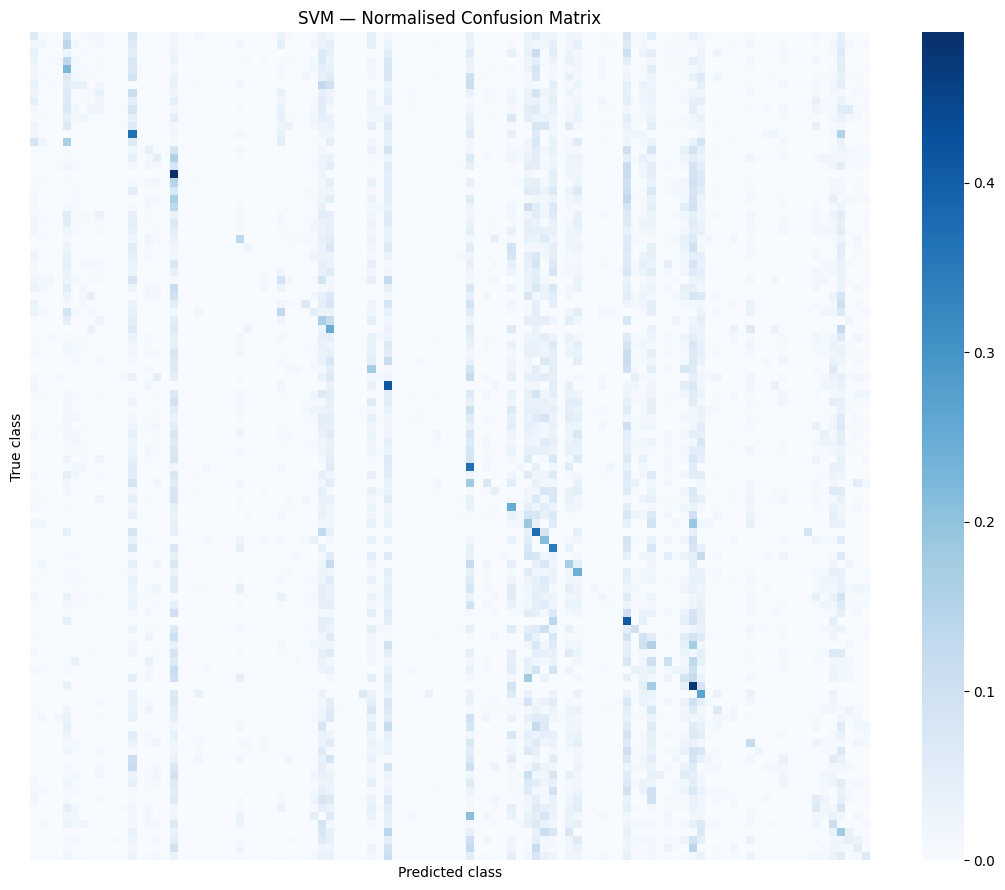

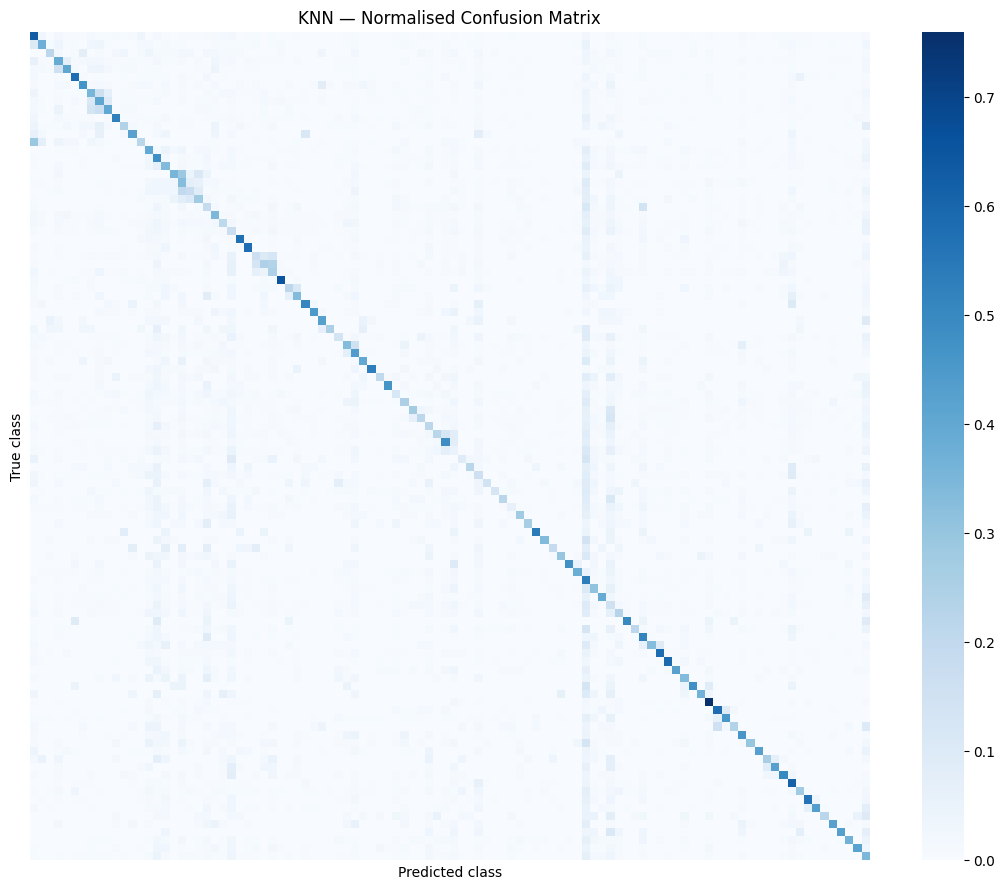

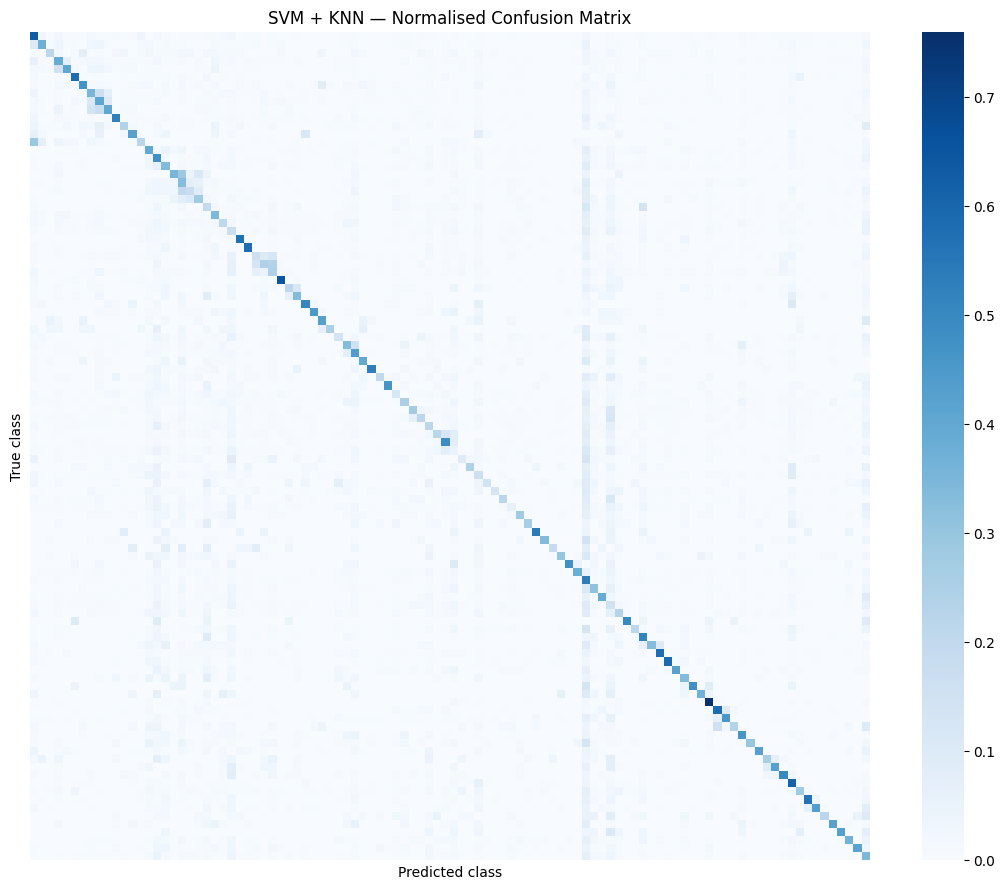

,precision,recall,f1-score,support
rice leaf roller,0.401141,0.629851,0.490128,335.0
rice leaf caterpillar,0.413534,0.374150,0.392857,147.0
paddy stem maggot,0.326923,0.215190,0.259542,79.0
asiatic rice borer,0.391720,0.389241,0.390476,316.0
yellow rice borer,0.449275,0.407895,0.427586,152.0
rice gall midge,0.497175,0.578947,0.534954,152.0
Rice Stemfly,0.388060,0.468468,0.424490,111.0
brown plant hopper,0.358566,0.358566,0.358566,251.0
white backed plant hopper,0.314121,0.406716,0.354472,268.0
small brown plant hopper,0.338384,0.403614,0.368132,166.0


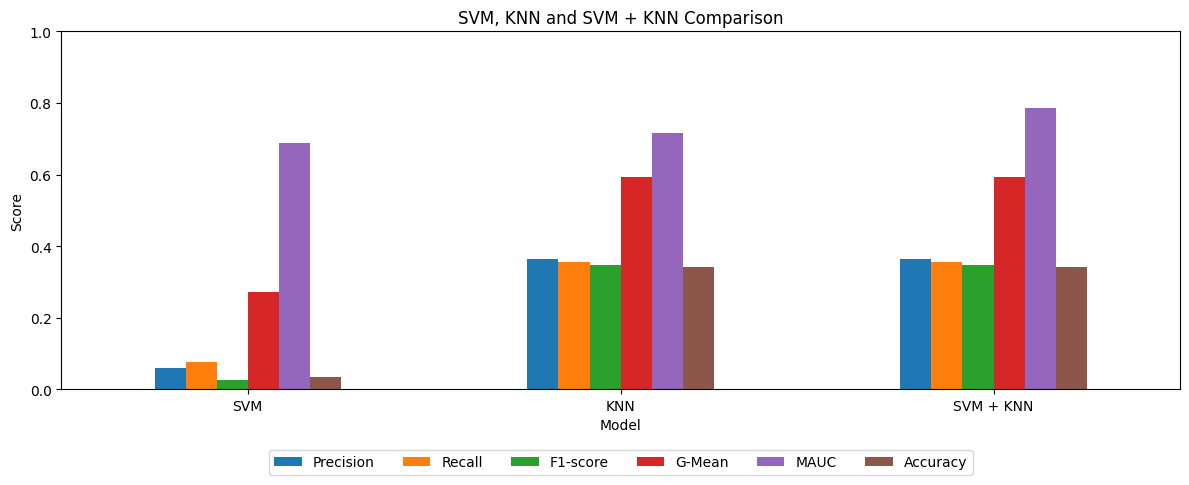

Model saved to: /content/drive/MyDrive/COMP9444_Project/models/svm_knn/svm_knn_ip102.joblib
Results saved to: /content/drive/MyDrive/COMP9444_Project/outputs/svm_knn/svm_knn_results.csv
Metrics saved to: /content/drive/MyDrive/COMP9444_Project/outputs/svm_knn/svm_knn_metrics.json


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import json
# Create variables for the group comparison table
result_index = svm_knn_results.set_index("Model")

svm_pre = result_index.loc["SVM", "Precision"]
svm_rec = result_index.loc["SVM", "Recall"]
svm_f1 = result_index.loc["SVM", "F1-score"]
svm_gm = result_index.loc["SVM", "G-Mean"]
svm_mauc = result_index.loc["SVM", "MAUC"]
svm_acc = result_index.loc["SVM", "Accuracy"]

knn_pre = result_index.loc["KNN", "Precision"]
knn_rec = result_index.loc["KNN", "Recall"]
knn_f1 = result_index.loc["KNN", "F1-score"]
knn_gm = result_index.loc["KNN", "G-Mean"]
knn_mauc = result_index.loc["KNN", "MAUC"]
knn_acc = result_index.loc["KNN", "Accuracy"]

svm_knn_pre = result_index.loc["SVM + KNN", "Precision"]
svm_knn_rec = result_index.loc["SVM + KNN", "Recall"]
svm_knn_f1 = result_index.loc["SVM + KNN", "F1-score"]
svm_knn_gm = result_index.loc["SVM + KNN", "G-Mean"]
svm_knn_mauc = result_index.loc["SVM + KNN", "MAUC"]
svm_knn_acc = result_index.loc["SVM + KNN", "Accuracy"]

print("Group comparison variables created successfully.")

# Plot normalised confusion matrices
for model_name, predictions in predictions_by_model.items():
    matrix = confusion_matrix(y_test, predictions, labels=np.arange(NUM_CLASSES), normalize="true")
    figure, axis = plt.subplots(figsize=(11, 9))
    sns.heatmap(matrix, cmap="Blues", xticklabels=False, yticklabels=False, ax=axis)
    axis.set_title(f"{model_name} — Normalised Confusion Matrix")
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")
    figure.tight_layout()
    safe_name = model_name.lower().replace(" ", "_").replace("+", "plus")
    figure.savefig(SVM_KNN_FIGURE_DIR / f"{safe_name}_confusion_matrix.png", dpi=180, bbox_inches="tight")
    plt.show()
# Generate the SVM + KNN per-class report
ensemble_predictions = predictions_by_model["SVM + KNN"]
ensemble_report = classification_report(
    y_test,
    ensemble_predictions,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    output_dict=True,
    zero_division=0)

per_class_report = pd.DataFrame(ensemble_report).transpose()
display(per_class_report.head(20))
per_class_report.to_csv(SVM_KNN_OUTPUT_DIR / "svm_knn_per_class_report.csv", encoding="utf-8-sig")

# Plot the final comparison chart
plot_columns = ["Precision", "Recall", "F1-score", "G-Mean", "MAUC", "Accuracy"]
axis = svm_knn_results.set_index("Model")[plot_columns].plot.bar(figsize=(12, 5), ylim=(0, 1), rot=0)
axis.set_title("SVM, KNN and SVM + KNN Comparison")
axis.set_xlabel("Model")
axis.set_ylabel("Score")
axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=6)
plt.tight_layout()
plt.savefig(SVM_KNN_FIGURE_DIR / "svm_knn_comparison.png", dpi=180, bbox_inches="tight")
plt.show()
# Save the trained models and preprocessing components
model_file = SVM_KNN_MODEL_DIR / "svm_knn_ip102.joblib"
joblib.dump(
    {
        "scaler": feature_scaler,
        "pca": pca,
        "svm": svm_model,
        "knn": knn_model,
        "svm_weight": svm_weight,
        "knn_weight": knn_weight,
        "class_order": class_order,
        "class_names": class_names,
        "feature_size": FEATURE_SIZE,
        "pca_components": number_of_components,
        "max_train_per_class": MAX_TRAIN_PER_CLASS,
        "seed": SEED
    },
    model_file
)
# Save the comparison results
comparison_csv = SVM_KNN_OUTPUT_DIR / "svm_knn_results.csv"
svm_knn_results.to_csv(comparison_csv, index=False, encoding="utf-8-sig")
# Save the metrics in JSON format
metrics_json = SVM_KNN_OUTPUT_DIR / "svm_knn_metrics.json"
metrics_json.write_text(json.dumps(svm_knn_results.to_dict(orient="records"), indent=2), encoding="utf-8")
print("Model saved to:", model_file)
print("Results saved to:", comparison_csv)
print("Metrics saved to:", metrics_json)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory     : FOUND
  /content/drive/MyDrive/COMP9444_Project
Dataset directory     : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset
Image directory       : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/images
Training split        : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/train.txt
Validation split      : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/val.txt
Test split            : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/test.txt
Class names           : FOUND
  /content/drive/MyDrive/COMP9444_Project/Dataset/classes.txt

Drive and dataset paths configured successfully.

SVM + KNN configuration:


,Parameter,Value
0,feature_size,64.0
1,pca_components,64.0
2,svm_c,1.0
3,knn_k,5.0
4,feature_workers,4.0
5,max_train_per_class,0.0
6,seed,42.0


Training records: 45095
Validation records: 7508
Test records: 22619

IP102 dataset summary:


,Split,Images,Classes
0,Train,45095,102
1,Validation,7508,102
2,Test,22619,102


Total number of classes: 102
First five classes: ['rice leaf roller', 'rice leaf caterpillar', 'paddy stem maggot', 'asiatic rice borer', 'yellow rice borer']

Smallest training class: 42
Largest training class: 3444
Average images per class: 442.11
Imbalance ratio: 82.0


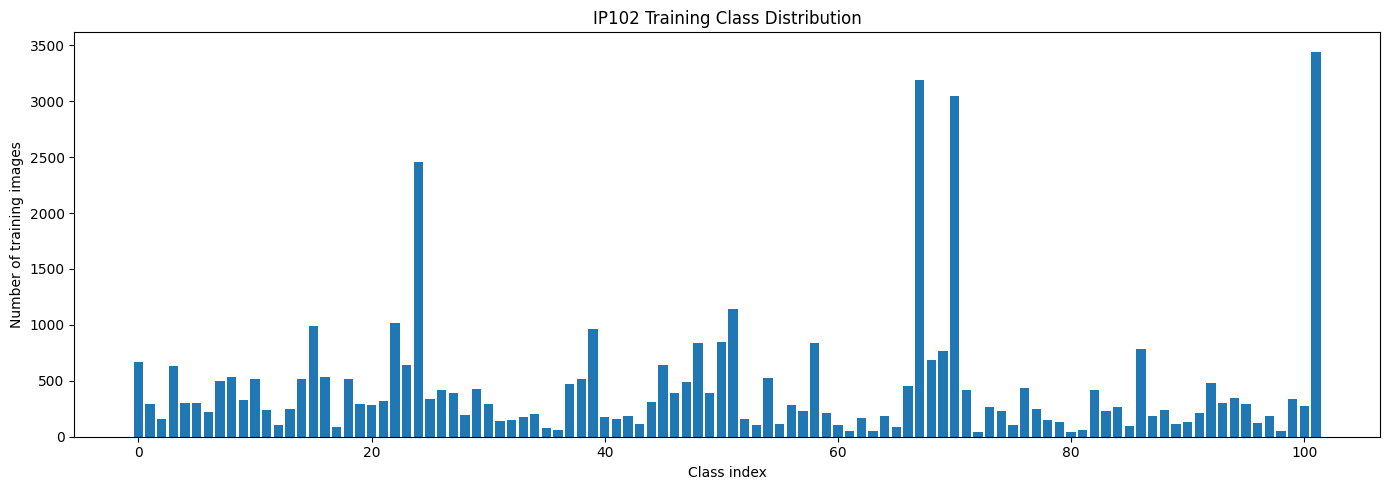

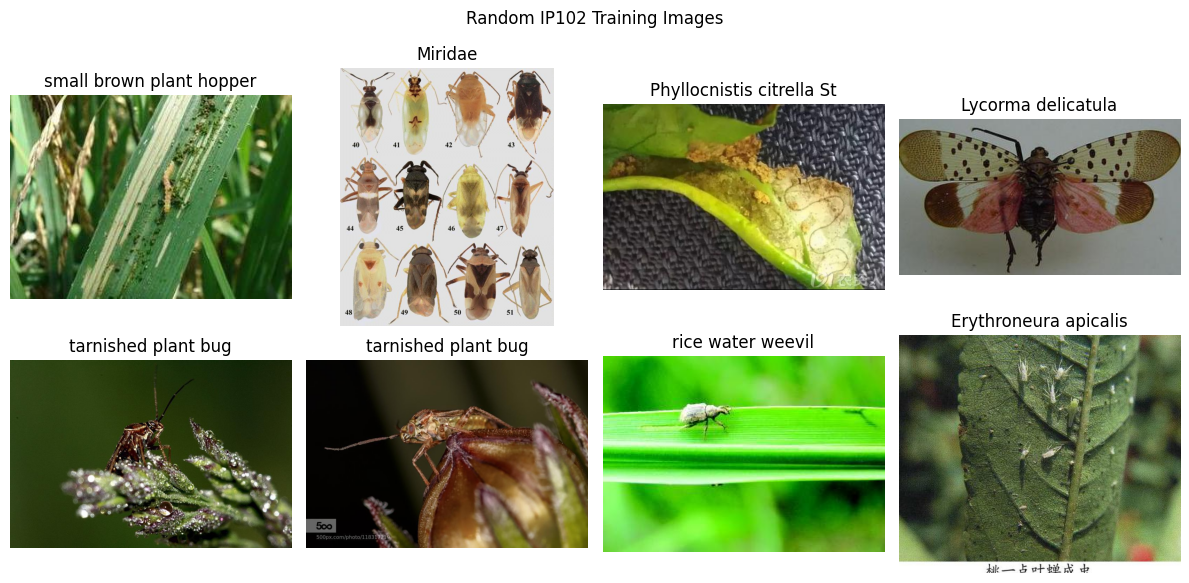


SVM + KNN setup and data loading completed successfully.
SVM + KNN outputs: /content/drive/MyDrive/COMP9444_Project/outputs/svm_knn
Feature cache: /content/drive/MyDrive/COMP9444_Project/cache


In [ ]:
!pip install -q scikit-image joblib seaborn

import json
import random
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from google.colab import drive
from IPython.display import display
from PIL import Image, ImageFile
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from skimage.color import rgb2gray, rgb2hsv
from skimage.feature import hog
from tqdm.auto import tqdm


ImageFile.LOAD_TRUNCATED_IMAGES = True
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
drive.mount(
    "/content/drive",
    force_remount=False,
)

PROJECT_DIR = Path(
    "/content/drive/MyDrive/COMP9444_Project"
)

DATASET_DIR = PROJECT_DIR / "Dataset"
IMAGE_DIR = DATASET_DIR / "images"
TRAIN_FILE = DATASET_DIR / "train.txt"
VAL_FILE = DATASET_DIR / "val.txt"
TEST_FILE = DATASET_DIR / "test.txt"
CLASSES_FILE = DATASET_DIR / "classes.txt"
# Main output directories
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"
CACHE_DIR = PROJECT_DIR / "cache"
# SVM + KNN output directories
SVM_KNN_OUTPUT_DIR = (
    OUTPUT_DIR / "svm_knn"
)

SVM_KNN_FIGURE_DIR = (
    FIGURE_DIR / "svm_knn"
)

for directory in [
    MODEL_DIR,
    OUTPUT_DIR,
    FIGURE_DIR,
    CACHE_DIR,
    SVM_KNN_OUTPUT_DIR,
    SVM_KNN_FIGURE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )
#Check dataset paths
required_paths = {
    "Project directory": PROJECT_DIR,
    "Dataset directory": DATASET_DIR,
    "Image directory": IMAGE_DIR,
    "Training split": TRAIN_FILE,
    "Validation split": VAL_FILE,
    "Test split": TEST_FILE,
    "Class names": CLASSES_FILE,
}
all_paths_found = True
for name, path in required_paths.items():
    exists = path.exists()
    print(
        f"{name:22}: "
        f"{'FOUND' if exists else 'MISSING'}"
    )
    print(f"  {path}")
    all_paths_found = (
        all_paths_found and exists
    )
if not all_paths_found:
    raise FileNotFoundError(
        "Some IP102 files are missing. "
        "Check the Google Drive paths."
    )
print(
    "\nDrive and dataset paths "
    "configured successfully."
)
#configuration
# Image size used for handcrafted features
FEATURE_SIZE = 64
# Number of PCA output features
PCA_COMPONENTS = 64
# SVM parameter
SVM_C = 1.0
# Number of neighbours
KNN_K = 5
# Number of CPU threads for feature extraction
FEATURE_WORKERS = 4
# Use 100 or 200 for faster testing. And in final test use 0
MAX_TRAIN_PER_CLASS = 0

configuration = {
    "feature_size": FEATURE_SIZE,
    "pca_components": PCA_COMPONENTS,
    "svm_c": SVM_C,
    "knn_k": KNN_K,
    "feature_workers": FEATURE_WORKERS,
    "max_train_per_class": (
        MAX_TRAIN_PER_CLASS
    ),
    "seed": SEED,
}
print("\nSVM + KNN configuration:")
display(
    pd.DataFrame(
        configuration.items(),
        columns=["Parameter", "Value"],
    )
)
# Read IP102 split files
def read_ip102_split(split_file):
    """
    Read an IP102 split file without calling exists()
    for every image on Google Drive.
    """
    samples = []
    lines = Path(split_file).read_text(
        encoding="utf-8"
    ).splitlines()

    for line in lines:
        if not line.strip():
            continue
        path_text, raw_label = (
            line.rsplit(maxsplit=1)
        )
        filename = Path(
            path_text
        ).name

        image_path = (
            IMAGE_DIR / filename
        )
        samples.append(
            (
                image_path,
                int(raw_label),
            )
        )
    return samples
raw_records = {
    "train": read_ip102_split(
        TRAIN_FILE
    ),
    "val": read_ip102_split(
        VAL_FILE
    ),
    "test": read_ip102_split(
        TEST_FILE
    ),
}
print(
    "Training records:",
    len(raw_records["train"]),
)
print(
    "Validation records:",
    len(raw_records["val"]),
)
print(
    "Test records:",
    len(raw_records["test"]),
)

def load_image_with_retry(
    image_path,
    maximum_attempts=5,
    wait_seconds=2,
):
    """
    Read an image from Google Drive with retries
    for temporary I/O errors.
    """

    last_error = None

    for attempt in range(
        1,
        maximum_attempts + 1,
    ):

        try:
            with Image.open(
                image_path
            ) as image:

                return image.convert(
                    "RGB"
                ).copy()

        except OSError as error:

            last_error = error

            print(
                f"Temporary read error "
                f"({attempt}/{maximum_attempts}): "
                f"{image_path.name}"
            )

            time.sleep(
                wait_seconds
            )

    raise OSError(
        f"Failed to read {image_path} "
        f"after {maximum_attempts} attempts."
    ) from last_error
# Create continuous labels
raw_train_labels = sorted({
    label
    for _, label
    in raw_records["train"]
})
label_map = {
    raw_label: new_label
    for new_label, raw_label
    in enumerate(raw_train_labels)
}
# Check validation and test labels
for split_name, samples in (
    raw_records.items()
):
    unknown_labels = {
        label
        for _, label in samples
        if label not in label_map
    }
    if unknown_labels:
        raise ValueError(
            f"{split_name} contains "
            "labels not present in "
            f"training data: {unknown_labels}"
        )
records = {
    split_name: [
        (
            image_path,
            label_map[raw_label],
        )
        for image_path, raw_label
        in samples
    ]
    for split_name, samples
    in raw_records.items()
}
class_lines = [
    line.strip()
    for line in CLASSES_FILE.read_text(
        encoding="utf-8"
    ).splitlines()
    if line.strip()
]
parsed_class_names = []
for line in class_lines:
    parts = line.split(
        maxsplit=1
    )
    if (
        len(parts) == 2
        and parts[0].isdigit()
    ):
        parsed_class_names.append(
            parts[1]
        )
    else:
        parsed_class_names.append(
            line
        )
if (
    len(parsed_class_names)
    == len(raw_train_labels)
):
    class_names = (
        parsed_class_names
    )
else:
    print(
        "Warning: classes.txt does not "
        "match the number of labels. "
        "Numeric labels will be used."
    )
    class_names = [
        str(raw_label)
        for raw_label
        in raw_train_labels
    ]
NUM_CLASSES = len(
    class_names
)
assert NUM_CLASSES == 102, (
    "Expected 102 classes, "
    f"found {NUM_CLASSES}."
)
# Dataset summary
dataset_summary = pd.DataFrame({
    "Split": [
        "Train",
        "Validation",
        "Test",
    ],
    "Images": [
        len(records["train"]),
        len(records["val"]),
        len(records["test"]),
    ],
    "Classes": [
        len({
            label
            for _, label
            in records["train"]
        }),
        len({
            label
            for _, label
            in records["val"]
        }),
        len({
            label
            for _, label
            in records["test"]
        }),
    ],
})
print("\nIP102 dataset summary:")
display(
    dataset_summary
)
print(
    "Total number of classes:",
    NUM_CLASSES,
)
print(
    "First five classes:",
    class_names[:5],
)
assert len(records["train"]) == 45095, (
    "Unexpected training split size."
)
assert len(records["val"]) == 7508, (
    "Unexpected validation split size."
)
assert len(records["test"]) == 22619, (
    "Unexpected test split size."
)
#Class distribution

train_labels = np.asarray([
    label
    for _, label
    in records["train"]
])
class_counts = np.bincount(
    train_labels,
    minlength=NUM_CLASSES,
)
print(
    "\nSmallest training class:",
    int(class_counts.min()),
)
print(
    "Largest training class:",
    int(class_counts.max()),
)
print(
    "Average images per class:",
    round(
        float(class_counts.mean()),
        2,
    ),
)
print(
    "Imbalance ratio:",
    round(
        float(
            class_counts.max()
            / class_counts.min()
        ),
        2,
    ),
)
plt.figure(
    figsize=(14, 5)
)
plt.bar(
    np.arange(NUM_CLASSES),
    class_counts,
)
plt.xlabel(
    "Class index"
)
plt.ylabel(
    "Number of training images"
)
plt.title(
    "IP102 Training Class Distribution"
)
plt.tight_layout()
plt.show()
#Display sample images
rng = np.random.default_rng(
    SEED
)
sample_indices = rng.choice(
    len(records["train"]),
    size=8,
    replace=False,
)
figure, axes = plt.subplots(
    2,
    4,
    figsize=(12, 6),
)
for axis, sample_index in zip(
    axes.flat,
    sample_indices,
):
    image_path, label = (
        records["train"][
            sample_index
        ]
    )
    with Image.open(
        image_path
    ) as image:
        axis.imshow(
            image.convert("RGB")
        )
    axis.set_title(
        class_names[label][:25]
    )
    axis.axis("off")
figure.suptitle(
    "Random IP102 Training Images"
)
plt.tight_layout()
plt.show()
print(
    "\nSVM + KNN setup and "
    "data loading completed successfully."
)
print(
    "SVM + KNN outputs:",
    SVM_KNN_OUTPUT_DIR,
)
print(
    "Feature cache:",
    CACHE_DIR,
)

In [ ]:
# ============================================================
# Select a balanced training subset for SVM + KNN
# ============================================================

def limit_samples_per_class(
    samples,
    maximum_per_class,
):
    """
    Randomly limit the number of training images
    in each class.

    maximum_per_class = 0:
        Use the complete training set.

    maximum_per_class > 0:
        Use at most the specified number of images
        from every class.
    """

    # Use the complete training set
    if maximum_per_class <= 0:
        return list(samples)

    rng = np.random.default_rng(
        SEED
    )

    grouped_samples = {}

    # Group images by class
    for image_path, label in samples:

        grouped_samples.setdefault(
            label,
            [],
        ).append(
            (
                image_path,
                label,
            )
        )

    selected_samples = []

    # Randomly select samples from each class
    for label in sorted(
        grouped_samples
    ):

        class_samples = (
            grouped_samples[label]
        )

        number_to_select = min(
            maximum_per_class,
            len(class_samples),
        )

        selected_indices = rng.choice(
            len(class_samples),
            size=number_to_select,
            replace=False,
        )

        selected_samples.extend([
            class_samples[index]
            for index in selected_indices
        ])

    # Shuffle the final selected dataset
    rng.shuffle(
        selected_samples
    )

    return selected_samples


# Apply the per-class limit
selected_train_records = (
    limit_samples_per_class(
        records["train"],
        MAX_TRAIN_PER_CLASS,
    )
)


# Count selected images in every class
selected_labels = np.asarray(
    [
        label
        for _, label
        in selected_train_records
    ],
    dtype=np.int64,
)


selected_counts = np.bincount(
    selected_labels,
    minlength=NUM_CLASSES,
)


# Display selection results
print(
    "Original training images:",
    len(records["train"]),
)

print(
    "Selected training images:",
    len(selected_train_records),
)

print(
    "Selected classes:",
    np.count_nonzero(
        selected_counts
    ),
)

print(
    "Smallest selected class:",
    selected_counts.min(),
)

print(
    "Largest selected class:",
    selected_counts.max(),
)


# Confirm all 102 classes are retained
assert (
    np.count_nonzero(
        selected_counts
    )
    == NUM_CLASSES
), "Some classes are missing."


# Check the limit only when it is enabled
if MAX_TRAIN_PER_CLASS > 0:

    assert (
        selected_counts.max()
        <= MAX_TRAIN_PER_CLASS
    ), "Per-class limit was not applied."


print(
    "\nTraining sample selection "
    "completed successfully."
)

Original training images: 45095
Selected training images: 45095
Selected classes: 102
Smallest selected class: 42
Largest selected class: 3444

Training sample selection completed successfully.


# The above SVM and KNN baseline used a maximum of 100 training images per class, retaining 9,813 training images across all 102 classes.

In [ ]:
def extract_image_feature(
    image_path
):
    image = load_image_with_retry(
        image_path
    )

    image = image.resize(
        (
            FEATURE_SIZE,
            FEATURE_SIZE,
        )
    )

    rgb = np.asarray(
        image,
        dtype=np.float32,
    ) / 255.0
    # HOG shape feature
    hog_feature = hog(
        rgb2gray(rgb),
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    )

    # HSV colour histogram
    hsv = rgb2hsv(rgb)

    colour_feature = np.concatenate([
        np.histogram(
            hsv[..., channel],
            bins=16,
            range=(0, 1),
            density=True,
        )[0]
        for channel in range(3)
    ])

    combined_feature = np.concatenate([
        hog_feature,
        colour_feature,
    ])

    return combined_feature.astype(
        np.float32
    )


def limit_samples_per_class(
    samples,
    maximum_per_class,
):
    """
    Optionally limit the number of training samples
    from each class.
    """

    if maximum_per_class <= 0:
        return samples

    rng = np.random.default_rng(SEED)

    grouped_samples = {}

    for sample in samples:
        label = sample[1]

        grouped_samples.setdefault(
            label,
            [],
        ).append(sample)

    selected_samples = []

    for label, class_samples in grouped_samples.items():
        sample_count = min(
            maximum_per_class,
            len(class_samples),
        )

        selected_indices = rng.choice(
            len(class_samples),
            size=sample_count,
            replace=False,
        )

        selected_samples.extend([
            class_samples[index]
            for index in selected_indices
        ])

    rng.shuffle(selected_samples)

    return selected_samples


def extract_split_features(
    samples,
    description,
):
    image_paths = [
        image_path
        for image_path, _ in samples
    ]

    labels = np.asarray(
        [
            label
            for _, label in samples
        ],
        dtype=np.int64,
    )

    with ThreadPoolExecutor(
        max_workers=FEATURE_WORKERS
    ) as executor:

        feature_list = list(
            tqdm(
                executor.map(
                    extract_image_feature,
                    image_paths,
                ),
                total=len(image_paths),
                desc=description,
            )
        )

    features = np.stack(feature_list)

    return features, labels


print(
    "Feature extraction functions created."
)

selected_train_records = (
    limit_samples_per_class(
        records["train"],
        MAX_TRAIN_PER_CLASS,
    )
)

cache_file = CACHE_DIR / (
    f"svm_knn_features_"
    f"size{FEATURE_SIZE}_"
    f"cap{MAX_TRAIN_PER_CLASS}.npz"
)

if cache_file.exists():

    print("Loading cached features:", cache_file)

    with np.load(cache_file) as cache:
        x_train = cache["x_train"]
        y_train = cache["y_train"]

        x_val = cache["x_val"]
        y_val = cache["y_val"]

        x_test = cache["x_test"]
        y_test = cache["y_test"]

else:

    x_train, y_train = extract_split_features(
        selected_train_records,
        "Extracting training features",
    )

    x_val, y_val = extract_split_features(
        records["val"],
        "Extracting validation features",
    )

    x_test, y_test = extract_split_features(
        records["test"],
        "Extracting test features",
    )

    np.savez_compressed(
        cache_file,
        x_train=x_train,
        y_train=y_train,
        x_val=x_val,
        y_val=y_val,
        x_test=x_test,
        y_test=y_test,
    )

    print("Feature cache saved:", cache_file)


print("Training features:", x_train.shape)
print("Validation features:", x_val.shape)
print("Test features:", x_test.shape)

Feature extraction functions created.


Extracting training features:   0%|          | 0/45095 [00:00<?, ?it/s]

In [ ]:
# Fit only on the training set
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(
    x_train
)
x_val_scaled = scaler.transform(
    x_val
)
x_test_scaled = scaler.transform(
    x_test
)
number_of_components = min(
    PCA_COMPONENTS,
    x_train_scaled.shape[0] - 1,
    x_train_scaled.shape[1],
)
pca = PCA(
    n_components=number_of_components,
    whiten=True,
    svd_solver="randomized",
    random_state=SEED,
)
x_train_final = pca.fit_transform(
    x_train_scaled
)
x_val_final = pca.transform(
    x_val_scaled
)
x_test_final = pca.transform(
    x_test_scaled
)

print("Original feature dimension:", x_train.shape[1],)
print("PCA feature dimension:", x_train_final.shape[1],)
print("Explained variance ratio:", pca.explained_variance_ratio_.sum(),)
print("Training PCA features:", x_train_final.shape,)
print("Validation PCA features:", x_val_final.shape,)
print("Test PCA features:", x_test_final.shape,)
print("Explained variance ratio:",round(float(pca.explained_variance_ratio_.sum()), 4,),)

Original feature dimension: 1812
PCA feature dimension: 64
Explained variance ratio: 0.48983568
Training PCA features: (9813, 64)
Validation PCA features: (7508, 64)
Test PCA features: (22619, 64)
Explained variance ratio: 0.4898


In [ ]:
svm_model = LinearSVC(
    C=SVM_C,
    class_weight="balanced",
    dual="auto",
    max_iter=5000,
    random_state=SEED,
)

knn_model = KNeighborsClassifier(
    n_neighbors=KNN_K,
    weights="distance",
    n_jobs=-1,
)


print("Training SVM")
svm_start_time = time.perf_counter()
svm_model.fit(
    x_train_final,
    y_train,
)
svm_training_time = (
    time.perf_counter()
    - svm_start_time
)

print("Training KNN")
knn_start_time = time.perf_counter()
knn_model.fit(
    x_train_final,
    y_train,
)
knn_training_time = (
    time.perf_counter()
    - knn_start_time
)
assert np.array_equal(
    svm_model.classes_,
    knn_model.classes_,
), "SVM and KNN class orders do not match."

print(
    f"SVM training time: "
    f"{svm_training_time:.2f} seconds"
)
print(
    f"KNN fitting time: "
    f"{knn_training_time:.2f} seconds"
)

Training SVM
Training KNN
SVM training time: 6.52 seconds
KNN fitting time: 0.00 seconds


In [ ]:
def stable_softmax(values):
    values = (
        values
        - values.max(
            axis=1,
            keepdims=True,
        )
    )
    exponential = np.exp(values)
    return (
        exponential
        / exponential.sum(
            axis=1,
            keepdims=True,
        )
    )
class_order = svm_model.classes_
svm_val_scores = stable_softmax(
    svm_model.decision_function(
        x_val_final
    )
)
knn_val_scores = knn_model.predict_proba(
    x_val_final
)
svm_val_predictions = class_order[
    svm_val_scores.argmax(axis=1)
]
knn_val_predictions = class_order[
    knn_val_scores.argmax(axis=1)
]
svm_val_accuracy = accuracy_score(
    y_val,
    svm_val_predictions,
)
knn_val_accuracy = accuracy_score(
    y_val,
    knn_val_predictions,
)
# Higher validation accuracy receives a higher weight
svm_weight = (
    svm_val_accuracy
    / max(
        svm_val_accuracy + knn_val_accuracy,
        1e-12,
    )
)
knn_weight = 1.0 - svm_weight
print("SVM validation accuracy:",svm_val_accuracy,)
print("KNN validation accuracy:", knn_val_accuracy,)
print("SVM ensemble weight:", svm_weight,)
print("KNN ensemble weight:", knn_weight,)

SVM validation accuracy: 0.03729355354288759
KNN validation accuracy: 0.14544485881726157
SVM ensemble weight: 0.20408163265306126
KNN ensemble weight: 0.7959183673469388


In [ ]:
def evaluate_classification_scores(
    y_true,
    scores,
    score_class_order,
):
    """
    Evaluate probability or decision score matrix.
    """
    highest_score_indices = scores.argmax(axis=1)
    predictions = score_class_order[highest_score_indices]
    top_k = min(5, scores.shape[1],)
    top_k_indices = np.argpartition(scores, -top_k, axis=1,)[:, -top_k:]
    top_k_labels = score_class_order[top_k_indices]
    top5_accuracy = np.mean([true_label in predicted_labels
        for true_label, predicted_labels
        in zip(y_true, top_k_labels)])
    metrics = {
        "test_accuracy": float(accuracy_score(y_true, predictions,)),
        "test_top5_accuracy": float(top5_accuracy),
        "test_macro_f1": float(f1_score(y_true, predictions, average="macro", zero_division=0,)),
        "test_weighted_f1": float(f1_score(y_true, predictions, average="weighted", zero_division=0,)),
        "test_balanced_accuracy": float(balanced_accuracy_score(y_true, predictions,)),
    }
    return metrics, predictions
# SVM test scores and latency
start_time = time.perf_counter()
svm_test_scores = stable_softmax(
    svm_model.decision_function(x_test_final)
)
svm_latency = (time.perf_counter() - start_time) * 1000 / len(x_test_final)
# KNN test scores and latency
start_time = time.perf_counter()
knn_test_scores = knn_model.predict_proba(x_test_final)
knn_latency = (time.perf_counter() - start_time) * 1000 / len(x_test_final)
# Validation-weighted ensemble
ensemble_test_scores = (
    svm_weight * svm_test_scores
    + knn_weight * knn_test_scores
)
model_score_data = {
    "svm": {
        "scores": svm_test_scores,
        "latency": svm_latency,
        "training_time": svm_training_time,
    },
    "knn": {
        "scores": knn_test_scores,
        "latency": knn_latency,
        "training_time": knn_training_time,
    },
    "svm_knn_ensemble": {
        "scores": ensemble_test_scores,
        "latency": (svm_latency + knn_latency),
        "training_time": (svm_training_time + knn_training_time),
    },
}
results = []
predictions_by_model = {}
for model_name, model_data in model_score_data.items():
    metrics, predictions = (
        evaluate_classification_scores(
            y_test,
            model_data["scores"],
            class_order,))
    metrics["latency_ms_per_image"] = float(model_data["latency"])
    metrics["training_time_seconds"] = float(model_data["training_time"])
    results.append({"model": model_name, **metrics,})
    predictions_by_model[model_name] = predictions
results_df = pd.DataFrame(results)
display(
    results_df.style.format(precision=4)
)

,model,test_accuracy,test_top5_accuracy,test_macro_f1,test_weighted_f1,test_balanced_accuracy,latency_ms_per_image,training_time_seconds
0,svm,0.0370,0.1423,0.0299,0.0287,0.0744,0.0216,6.5224
1,knn,0.1433,0.2241,0.1718,0.1359,0.2350,0.1866,0.0046
2,svm_knn_ensemble,0.1436,0.2234,0.1721,0.1363,0.2353,0.2083,6.5271


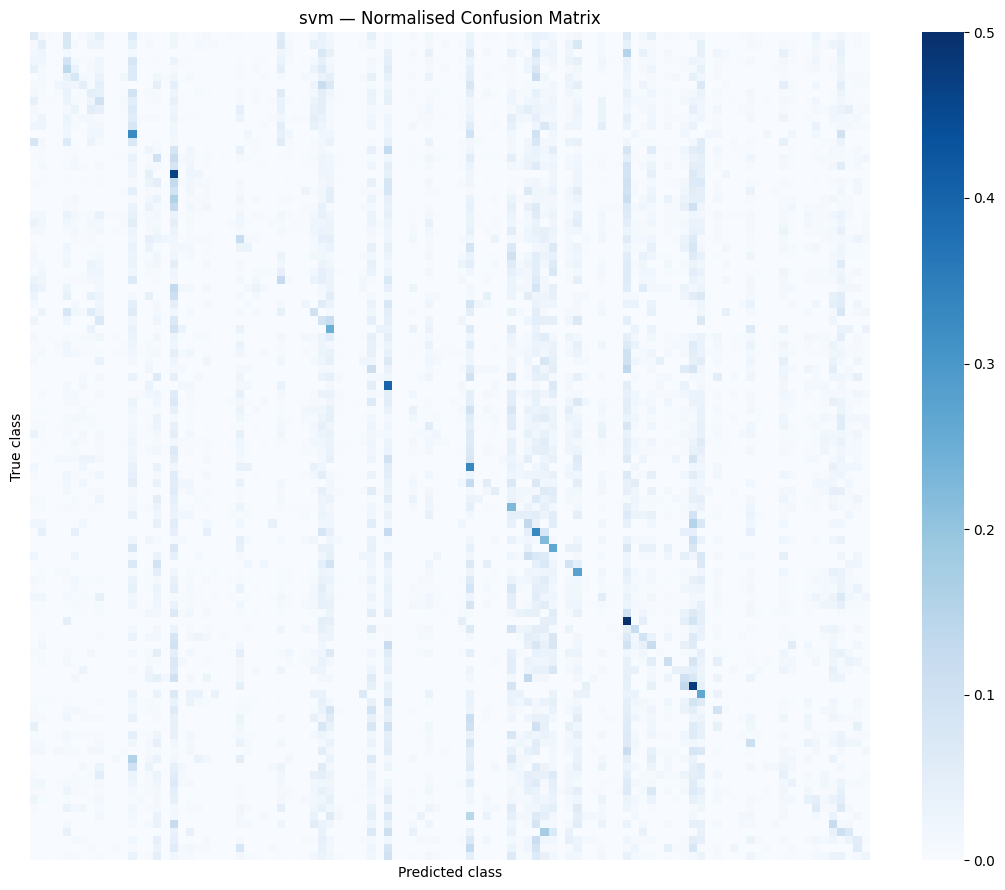

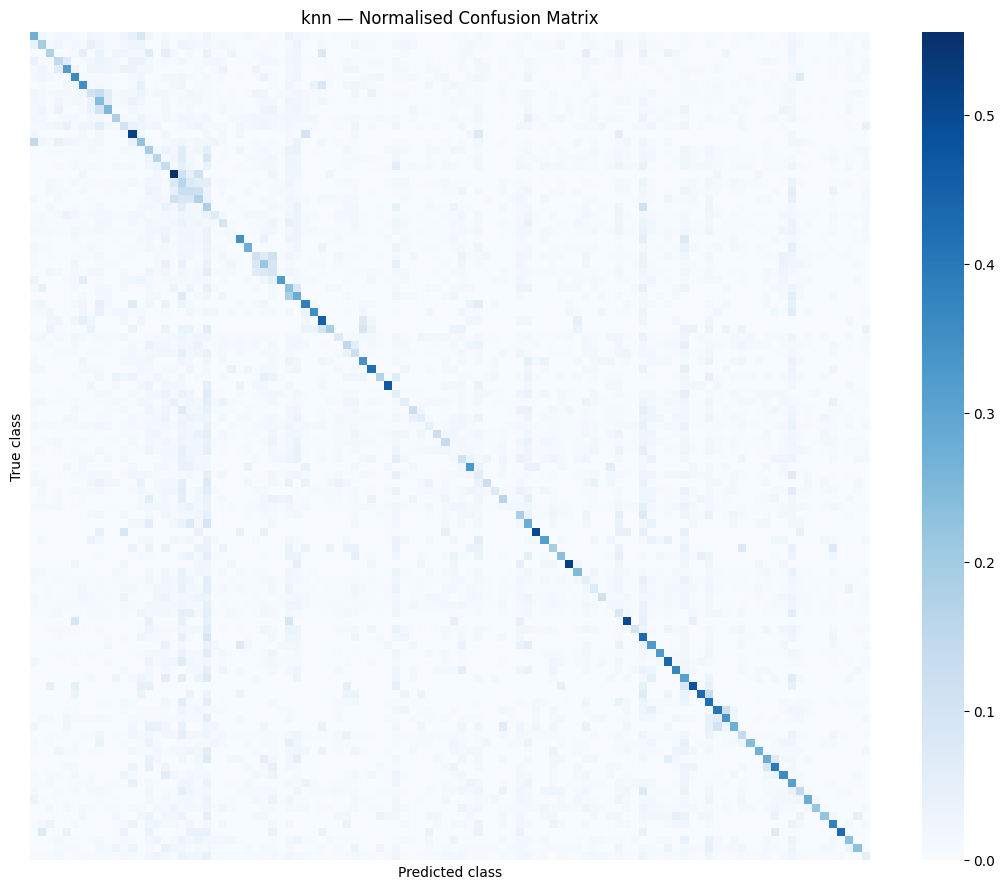

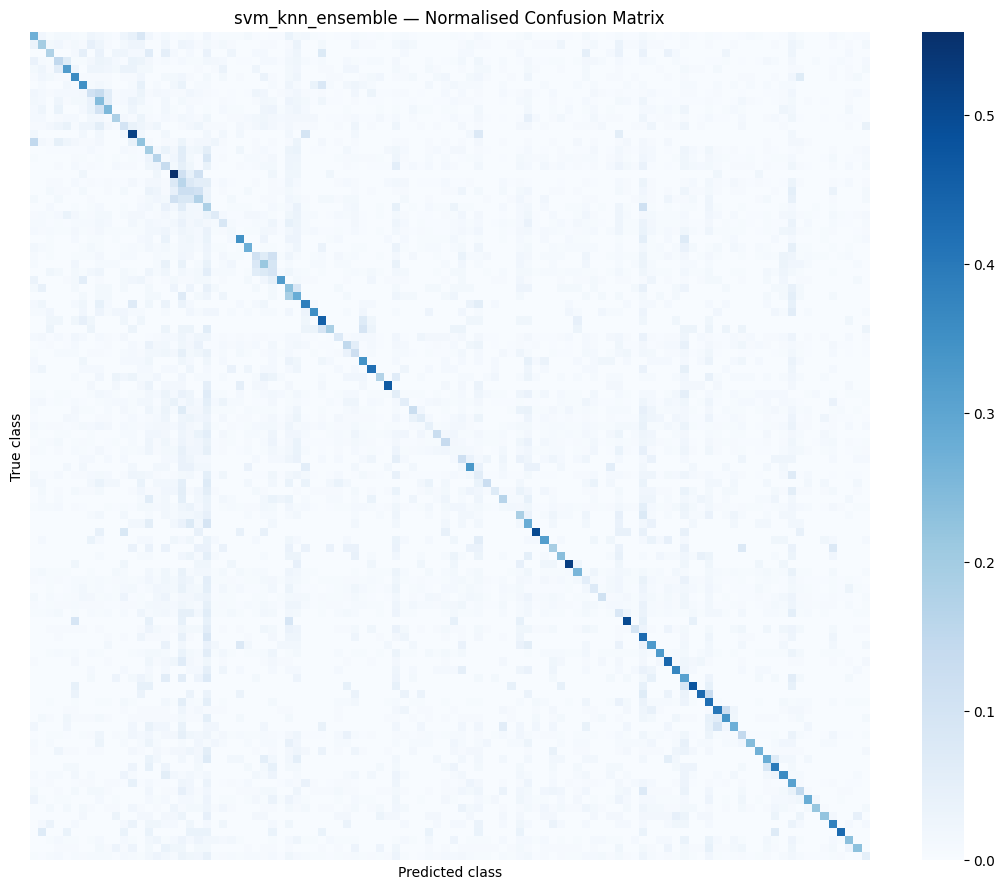

,precision,recall,f1-score,support
rice leaf roller,0.329710,0.271642,0.297872,335.0
rice leaf caterpillar,0.197279,0.197279,0.197279,147.0
paddy stem maggot,0.102190,0.177215,0.129630,79.0
asiatic rice borer,0.210046,0.145570,0.171963,316.0
yellow rice borer,0.272222,0.322368,0.295181,152.0
rice gall midge,0.217391,0.361842,0.271605,152.0
Rice Stemfly,0.202073,0.351351,0.256579,111.0
brown plant hopper,0.131068,0.107570,0.118162,251.0
white backed plant hopper,0.188953,0.242537,0.212418,268.0
small brown plant hopper,0.208955,0.253012,0.228883,166.0


In [ ]:
for model_name, predictions in (
    predictions_by_model.items()
):
    matrix = confusion_matrix(
        y_test,
        predictions,
        labels=np.arange(NUM_CLASSES),
        normalize="true",
    )
    figure, axis = plt.subplots(figsize=(11, 9))
    sns.heatmap(
        matrix,
        cmap="Blues",
        xticklabels=False,
        yticklabels=False,
        ax=axis,
    )
    axis.set_title(f"{model_name} — Normalised Confusion Matrix")
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("True class")
    figure.tight_layout()
    figure.savefig(
        SVM_KNN_FIGURE_DIR
        / f"{model_name}_confusion_matrix.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()

    ensemble_predictions = (predictions_by_model["svm_knn_ensemble"])

ensemble_report = classification_report(
    y_test,
    ensemble_predictions,
    labels=np.arange(NUM_CLASSES),
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

per_class_report = (
    pd.DataFrame(ensemble_report).transpose()
)

display(
    per_class_report.head(20)
)

per_class_report.to_csv(
    SVM_KNN_OUTPUT_DIR
    / "ensemble_per_class_report.csv"
)

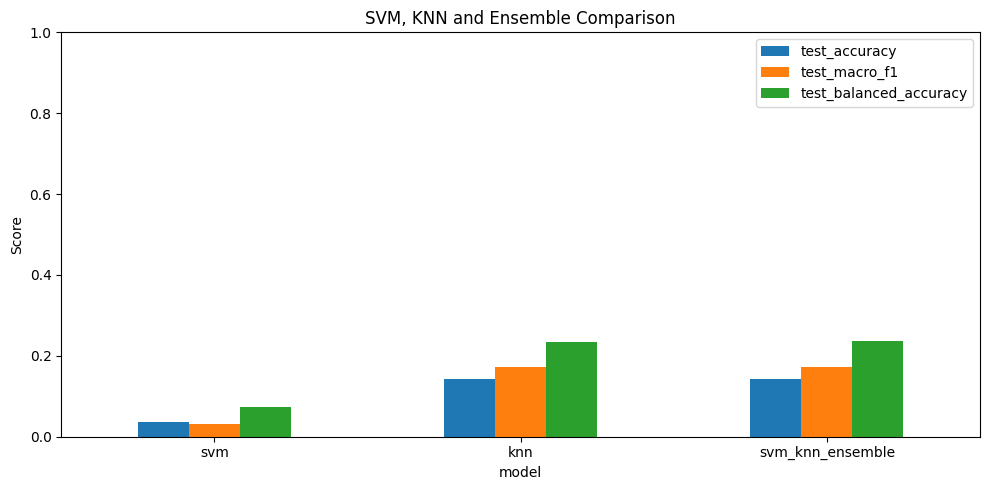

Model saved to:
/content/drive/MyDrive/COMP9444_Project/models/svm_knn_ip102.joblib

Comparison saved to:
/content/drive/MyDrive/COMP9444_Project/outputs/svm_knn/svm_knn_comparison.csv

Metrics saved to:
/content/drive/MyDrive/COMP9444_Project/outputs/svm_knn/svm_knn_metrics.json


In [ ]:
model_file = (
    MODEL_DIR
    / "svm_knn_ip102.joblib"
)

joblib.dump(
    {
        "scaler": scaler,
        "pca": pca,
        "svm": svm_model,
        "knn": knn_model,
        "svm_weight": svm_weight,
        "knn_weight": knn_weight,
        "class_order": class_order,
        "class_names": class_names,
        "feature_size": FEATURE_SIZE,
        "pca_components": number_of_components,
        "max_train_per_class": (
            MAX_TRAIN_PER_CLASS
        ),
        "seed": SEED,
    },
    model_file,
)
comparison_csv = (SVM_KNN_OUTPUT_DIR / "svm_knn_comparison.csv")
results_df.to_csv(comparison_csv, index=False,)
metrics_json = (SVM_KNN_OUTPUT_DIR  / "svm_knn_metrics.json")
metrics_json.write_text(
    json.dumps(results, indent=2,),encoding="utf-8",
)
plot_columns = [
    "test_accuracy",
    "test_macro_f1",
    "test_balanced_accuracy",
]

axis = (
    results_df.set_index("model")[plot_columns]
    .plot.bar(
        figsize=(10, 5),
        ylim=(0, 1),
        rot=0,)
)
axis.set_title(
    "SVM, KNN and Ensemble Comparison"
)
axis.set_ylabel("Score")
plt.tight_layout()
plt.savefig(
    SVM_KNN_FIGURE_DIR / "svm_knn_comparison.png",
    dpi=180, bbox_inches="tight",
)

plt.show()
print("Model saved to:")
print(model_file)
print("\nComparison saved to:")
print(comparison_csv)
print("\nMetrics saved to:")
print(metrics_json)

In [ ]:
# ============================================================
# Evaluate PRE, Recall, F1, GM, MAUC and ACC
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)


def evaluate_required_metrics(
    y_true,
    scores,
    class_order,
):
    """
    Calculate:
        PRE   - Macro Precision
        Recall - Macro Recall
        F1    - Macro F1-score
        GM    - Geometric mean of per-class recall
        MAUC  - Macro multiclass ROC-AUC (One-vs-Rest)
        ACC   - Overall accuracy
    """

    scores = np.asarray(
        scores,
        dtype=np.float64,
    )

    class_order = np.asarray(
        class_order
    )

    # Convert score matrix into predicted labels
    predicted_indices = scores.argmax(
        axis=1
    )

    predictions = class_order[
        predicted_indices
    ]

    # Macro Precision
    pre = precision_score(
        y_true,
        predictions,
        labels=class_order,
        average="macro",
        zero_division=0,
    )

    # Macro Recall
    recall = recall_score(
        y_true,
        predictions,
        labels=class_order,
        average="macro",
        zero_division=0,
    )

    # Macro F1-score
    f1 = f1_score(
        y_true,
        predictions,
        labels=class_order,
        average="macro",
        zero_division=0,
    )

    # Accuracy
    acc = accuracy_score(
        y_true,
        predictions,
    )

    # Recall of every class
    per_class_recall = recall_score(
        y_true,
        predictions,
        labels=class_order,
        average=None,
        zero_division=0,
    )

    # Geometric Mean of per-class recalls
    # If any class has zero recall, exact GM is zero
    if np.any(per_class_recall <= 0):
        gm = 0.0
    else:
        gm = float(
            np.exp(
                np.mean(
                    np.log(per_class_recall)
                )
            )
        )

    # Ensure scores are non-negative
    scores = np.maximum(
        scores,
        0.0,
    )

    # Normalise each row for multiclass AUC
    row_sums = scores.sum(
        axis=1,
        keepdims=True,
    )

    scores = scores / np.maximum(
        row_sums,
        1e-12,
    )

    # Macro Multiclass AUC using One-vs-Rest
    try:
        mauc = roc_auc_score(
            y_true,
            scores,
            labels=class_order,
            multi_class="ovr",
            average="macro",
        )

    except ValueError as error:
        print(
            "MAUC could not be calculated:",
            error,
        )
        mauc = np.nan

    return {
        "PRE": float(pre),
        "Recall": float(recall),
        "F1": float(f1),
        "GM": float(gm),
        "MAUC": float(mauc),
        "ACC": float(acc),
    }


# ============================================================
# Correct validation-weighted ensemble
# Important: use addition, not subtraction
# ============================================================

ensemble_test_scores = (
    svm_weight * svm_test_scores
    + knn_weight * knn_test_scores
)


# Scores for all three models
evaluation_models = {
    "SVM": svm_test_scores,
    "KNN": knn_test_scores,
    "SVM_KNN_Ensemble": ensemble_test_scores,
}


# Calculate metrics
required_metric_results = []

for model_name, model_scores in evaluation_models.items():

    metrics = evaluate_required_metrics(
        y_true=y_test,
        scores=model_scores,
        class_order=class_order,
    )

    required_metric_results.append({
        "Model": model_name,
        **metrics,
    })


# Create result table
required_metrics_df = pd.DataFrame(
    required_metric_results
)


# Display as percentages
display(
    required_metrics_df.style.format({
        "PRE": "{:.2%}",
        "Recall": "{:.2%}",
        "F1": "{:.2%}",
        "GM": "{:.2%}",
        "MAUC": "{:.2%}",
        "ACC": "{:.2%}",
    })
)